In [ ]:
df = pd.DataFrame(obj1.stats)
df["Ordered_time"] = df["Ordered_time"] + df["Customer_Arrived"]
df["Ordered_time"] = df["Ordered_time"] + df["Customer_Arrived"]
df["Production_time"] = df["Production_time"] + df["Customer_Arrived"]
df["Hand-off/Exit"] = df["Hand-off/Exit"] + df["Customer_Arrived"]


,Time,Customer_Id,Customer_Arrived,Ordered_time,Production_time,order_fullfillment,Hand-off/Exit,Left_with_out_ordering
0,4.080241,Customer:001,4.080241,13.574797,11.911543,8.953361,13.033602,0
1,4.181557,Customer:002,4.181557,14.312484,13.049537,10.198615,40.078317,0
2,9.515927,Customer:003,9.515927,30.129383,23.990269,16.029216,25.545143,0
3,9.623505,Customer:004,9.623505,30.417340,24.016840,15.803576,25.427081,0
4,12.772822,Customer:005,12.772822,40.172200,30.778296,19.742517,59.369207,0
...,...,...,...,...,...,...,...,...
717,1182.973470,Customer:718,1182.973470,3550.723037,2371.423861,1189.885338,2372.858808,0
718,1185.896698,Customer:719,1185.896698,3559.072797,2375.747535,1191.310314,NaN,0
719,1185.939042,Customer:720,1185.939042,3559.249356,2376.193176,1191.911015,2377.850057,0
720,1187.152632,Customer:721,1187.152632,3563.222117,2378.794716,1193.332899,NaN,0


#### **How Many people left with out ordering**

In [31]:
df["Hour"] = (df['Time'] / 60).astype(int)
df_left_with_out_ordering = df.loc[df["Left_with_out_ordering"] == 1]
left_with_out_ordering = df_left_with_out_ordering.groupby(["Hour"])[["Left_with_out_ordering"]].agg("count").reset_index()
time_labels = {
    0: "06:00 - 07:00", 1: "07:00 - 08:00", 2: "08:00 - 09:00",
    3: "09:00 - 10:00", 4: "10:00 - 11:00", 5: "11:00 - 12:00",
    6: "12:00 - 13:00", 7: "13:00 - 14:00", 8: "14:00 - 15:00",
    9: "15:00 - 16:00", 10: "16:00 - 17:00", 11: "17:00 - 18:00",
    12: "18:00 - 19:00", 13: "19:00 - 20:00", 14: "20:00 - 21:00",
    15: "21:00 - 22:00", 16: "22:00 - 23:00", 17: "23:00 - 00:00",
    18: "00:00 - 01:00", 19: "01:00 - 02:00"
}

left_with_out_ordering["Hour"] = left_with_out_ordering["Hour"].replace(time_labels)
left_with_out_ordering

,Hour,Left_with_out_ordering


#### **Utilization Rates of resource**

In [ ]:
df_util = pd.DataFrame(obj1.util_log)
df_util["Hour"] = (df_util['Time'] / 60).astype(int)
hourly_stats = df_util.groupby("Hour").mean().reset_index()
hourly_stats["Front_counter_Associate"] = (hourly_stats['Front_counter_Associate'] / obj1.associate.capacity) * 100
hourly_stats["Cook"] = (hourly_stats["Cook"]/obj1.cook.capacity)*100
hourly_stats["Order_fullfillment_Associate"] = (hourly_stats["Order_fullfillment_Associate"]/obj1.order_fullfillment.capacity)*100

time_labels = {
    0: "06:00 - 07:00", 1: "07:00 - 08:00", 2: "08:00 - 09:00",
    3: "09:00 - 10:00", 4: "10:00 - 11:00", 5: "11:00 - 12:00",
    6: "12:00 - 13:00", 7: "13:00 - 14:00", 8: "14:00 - 15:00",
    9: "15:00 - 16:00", 10: "16:00 - 17:00", 11: "17:00 - 18:00",
    12: "18:00 - 19:00", 13: "19:00 - 20:00", 14: "20:00 - 21:00",
    15: "21:00 - 22:00", 16: "22:00 - 23:00", 17: "23:00 - 00:00",
    18: "00:00 - 01:00", 19: "01:00 - 02:00"
}
hourly_stats["Hour"] = hourly_stats["Hour"].replace(time_labels)
hourly_stats

,Hour,Time,Front_counter_Associate,Cook,Order_fullfillment_Associate,Production_Wait_Queue,Order_Fullfillment_Associate_queue,Front_Counter_Associate_queue
0,06:00 - 07:00,30.000,20.427422,21.787399,20.704968,0.000000,0.000000,0.000000
1,07:00 - 08:00,90.025,16.555556,35.138889,33.888889,0.008333,0.010000,0.000000
2,08:00 - 09:00,150.000,34.250765,58.798999,55.045872,0.319433,0.088407,0.035863
3,09:00 - 10:00,209.975,35.666667,53.000000,57.166667,0.149167,0.030000,0.040000
4,10:00 - 11:00,269.975,22.944444,34.861111,33.555556,0.041667,0.035000,0.008333
5,11:00 - 12:00,329.975,52.333333,78.055556,74.722222,2.809167,0.034167,0.047500
6,12:00 - 13:00,389.975,87.444444,100.000000,102.222222,19.761667,0.198333,0.205833
7,13:00 - 14:00,449.975,52.055556,100.000000,98.611111,19.092500,0.170833,0.118333
8,14:00 - 15:00,509.975,36.666667,70.055556,73.833333,2.166667,0.040833,0.000000
9,15:00 - 16:00,569.975,25.166667,42.972222,42.666667,0.012500,0.022500,0.012500


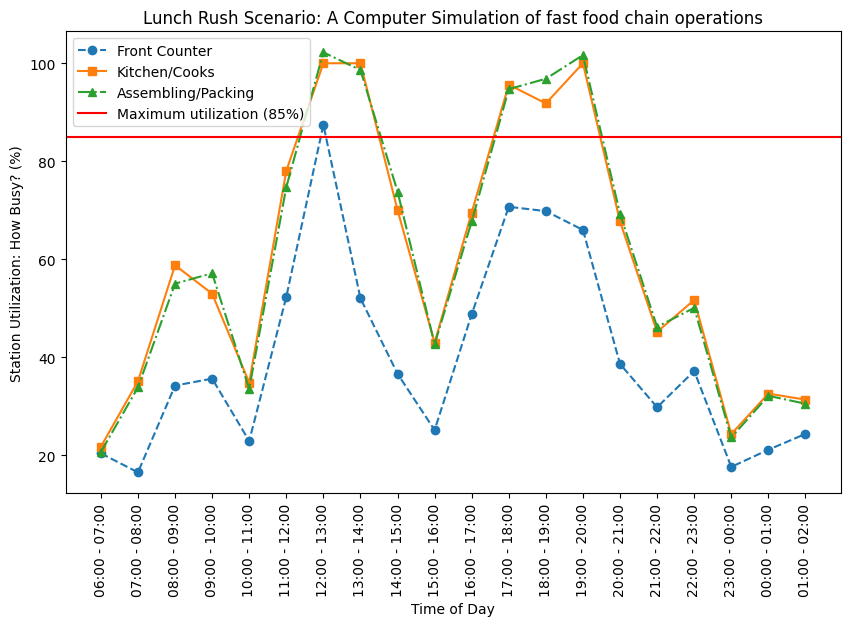

In [33]:
plt.figure(figsize=(10,6))
plt.plot(  hourly_stats["Hour"],  hourly_stats["Front_counter_Associate"], label = "Front Counter", ls = "--" , marker = "o")
plt.plot( hourly_stats["Hour"],  hourly_stats["Cook"], label= "Kitchen/Cooks" , ls = "-", marker = "s")
plt.plot( hourly_stats["Hour"],  hourly_stats["Order_fullfillment_Associate"], label= "Assembling/Packing", ls = "-.", marker = "^" )
plt.axhline( y = 85, color = "r", linestyle = "-", label="Maximum utilization (85%)")
plt.xticks(rotation = 90)
plt.xlabel("Time of Day")
plt.ylabel("Station Utilization: How Busy? (%)")
plt.title("Lunch Rush Scenario: A Computer Simulation of fast food chain operations")
plt.legend(loc = "upper left")
plt.show()